<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/%EC%9C%A4%EC%84%B8%EC%B0%AC_K_Means_%EC%8B%9C%EA%B0%81%ED%99%94_%EC%8B%A4%EC%8A%B5_%EC%BD%94%EB%93%9C%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 23.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 데이터 준비
X = np.array([
    [1, 1], [2, 1], [1, 2], [2, 2],[5,1],
    [5, 4], [6, 4], [5, 5], [6, 5]
])
K = 2
random_indices = np.random.choice(len(X), K, replace=False)
centroids = X[random_indices].copy()

# 색상 설정 (0번 그룹: 빨강, 1번 그룹: 파랑)
colors = ['red', 'blue']

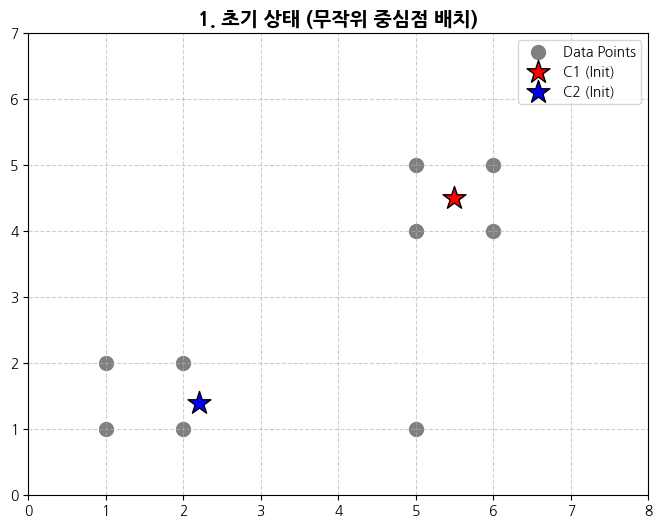

In [ ]:
# ==========================================
# [Step 1] 초기 상태 (Initial State)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c='gray', s=100, label='Data Points')
ax.scatter(centroids[0, 0], centroids[0, 1], c=colors[0], marker='*', s=300, edgecolor='black', label='C1 (Init)')
ax.scatter(centroids[1, 0], centroids[1, 1], c=colors[1], marker='*', s=300, edgecolor='black', label='C2 (Init)')

ax.set_title("1. 초기 상태 (무작위 중심점 배치)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 8)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show() # 그래프 창을 닫아야 다음 코드가 실행됩니다.

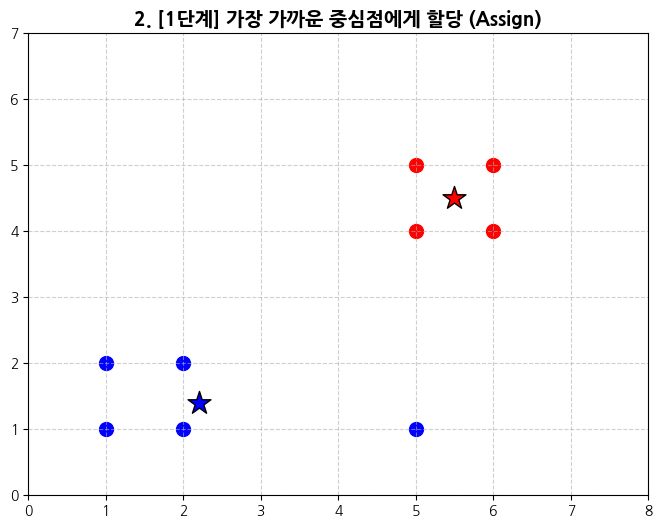

In [ ]:
# ==========================================
# [Step 2] 1차 군집 할당 (Assign)
# ==========================================
# 각 데이터 포인트가 C1과 C2 중 어디에 더 가까운지 계산합니다.
labels = []
for point in X:
    # 유클리드 거리 계산 (직선 거리)
    dist_to_c1 = np.sqrt((point[0] - centroids[0, 0])**2 + (point[1] - centroids[0, 1])**2)
    dist_to_c2 = np.sqrt((point[0] - centroids[1, 0])**2 + (point[1] - centroids[1, 1])**2)

    # 더 가까운 쪽의 인덱스를 저장 (0이면 C1, 1이면 C2)
    if dist_to_c1 < dist_to_c2:
        labels.append(0)
    else:
        labels.append(1)

labels = np.array(labels)

fig, ax = plt.subplots(figsize=(8, 6))
# 소속된 그룹의 색상으로 데이터 포인트 칠하기
for i in range(len(X)):
    ax.scatter(X[i, 0], X[i, 1], c=colors[labels[i]], s=100)

ax.scatter(centroids[0, 0], centroids[0, 1], c=colors[0], marker='*', s=300, edgecolor='black')
ax.scatter(centroids[1, 0], centroids[1, 1], c=colors[1], marker='*', s=300, edgecolor='black')

ax.set_title("2. [1단계] 가장 가까운 중심점에게 할당 (Assign)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 8)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show() # Step 2 확인 완료 후 창 닫기

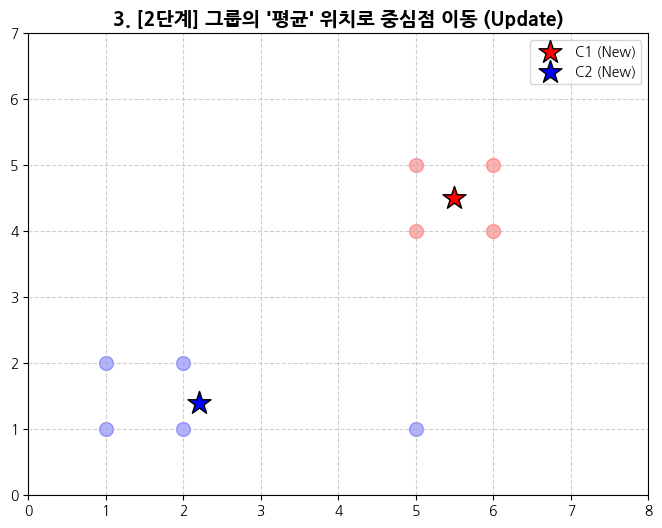

In [ ]:
# ==========================================
# [Step 3] 중심점 업데이트 계산 및 궤적 표시 (Update)
# ==========================================
new_centroids = np.zeros((2, 2))

# 그룹 0 (빨강)의 새로운 평균 위치 계산
group_0_points = X[labels == 0]
new_centroids[0] = np.mean(group_0_points, axis=0) # x, y 각각의 평균

# 그룹 1 (파랑)의 새로운 평균 위치 계산
group_1_points = X[labels == 1]
new_centroids[1] = np.mean(group_1_points, axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
# 데이터 포인트 그리기 (투명도를 주어 중심점 이동에 집중하게 함)
for i in range(len(X)):
    ax.scatter(X[i, 0], X[i, 1], c=colors[labels[i]], s=100, alpha=0.3)

# 예전 중심점 그리기 (투명하게)
ax.scatter(centroids[0, 0], centroids[0, 1], c=colors[0], marker='*', s=300, alpha=0.3)
ax.scatter(centroids[1, 0], centroids[1, 1], c=colors[1], marker='*', s=300, alpha=0.3)

# 새로운 중심점 그리기
ax.scatter(new_centroids[0, 0], new_centroids[0, 1], c=colors[0], marker='*', s=300, edgecolor='black', label='C1 (New)')
ax.scatter(new_centroids[1, 0], new_centroids[1, 1], c=colors[1], marker='*', s=300, edgecolor='black', label='C2 (New)')

# 이동 궤적을 화살표로 그리기
ax.annotate('', xy=new_centroids[0], xytext=centroids[0],
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))
ax.annotate('', xy=new_centroids[1], xytext=centroids[1],
            arrowprops=dict(facecolor='blue', shrink=0.05, width=2, headwidth=8))

ax.set_title("3. [2단계] 그룹의 '평균' 위치로 중심점 이동 (Update)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 8)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show() # Step 3 궤적 확인 완료 후 창 닫기


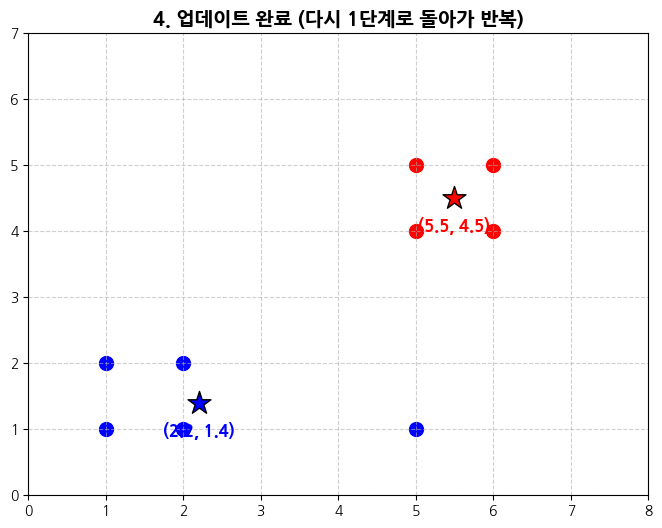

In [ ]:
# ==========================================
# [Step 4] 이동 완료된 모습
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(X)):
    ax.scatter(X[i, 0], X[i, 1], c=colors[labels[i]], s=100)

ax.scatter(new_centroids[0, 0], new_centroids[0, 1], c=colors[0], marker='*', s=300, edgecolor='black')
ax.scatter(new_centroids[1, 0], new_centroids[1, 1], c=colors[1], marker='*', s=300, edgecolor='black')

# 바뀐 위치 텍스트로 표시
ax.text(new_centroids[0,0], new_centroids[0,1]-0.5, f"({new_centroids[0,0]:.1f}, {new_centroids[0,1]:.1f})",
        fontsize=12, ha='center', color='red', fontweight='bold')
ax.text(new_centroids[1,0], new_centroids[1,1]-0.5, f"({new_centroids[1,0]:.1f}, {new_centroids[1,1]:.1f})",
        fontsize=12, ha='center', color='blue', fontweight='bold')
centroids = new_centroids

ax.set_title("4. 업데이트 완료 (다시 1단계로 돌아가 반복)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 8)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show() # 마지막 최종 상태 확인

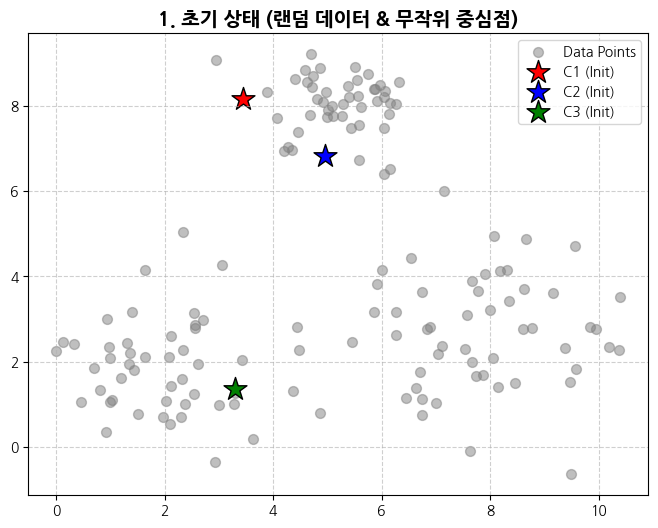

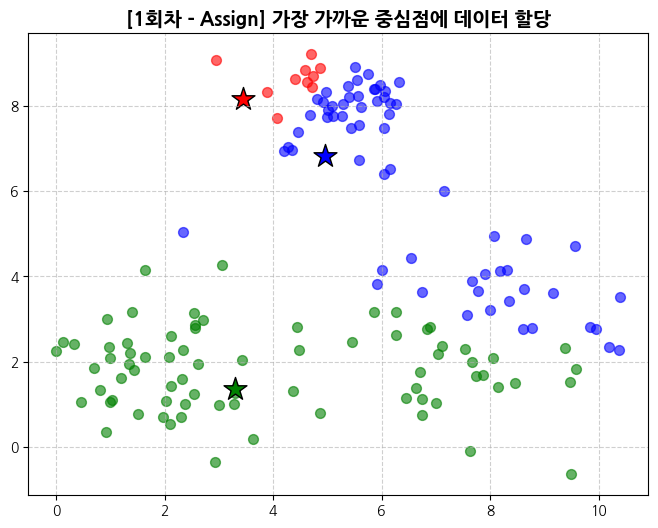

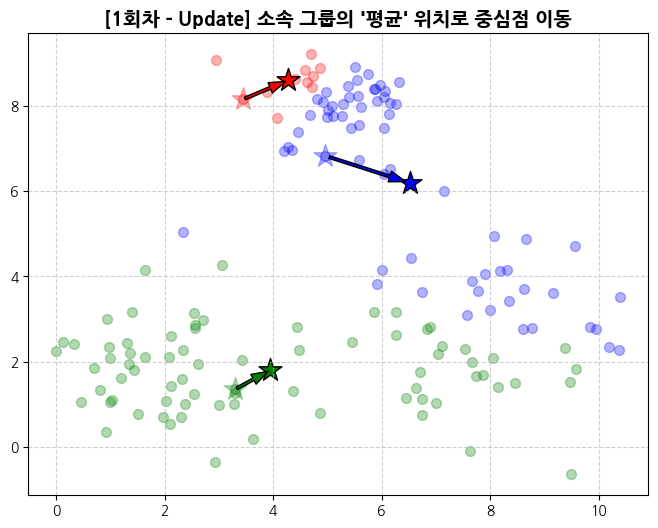

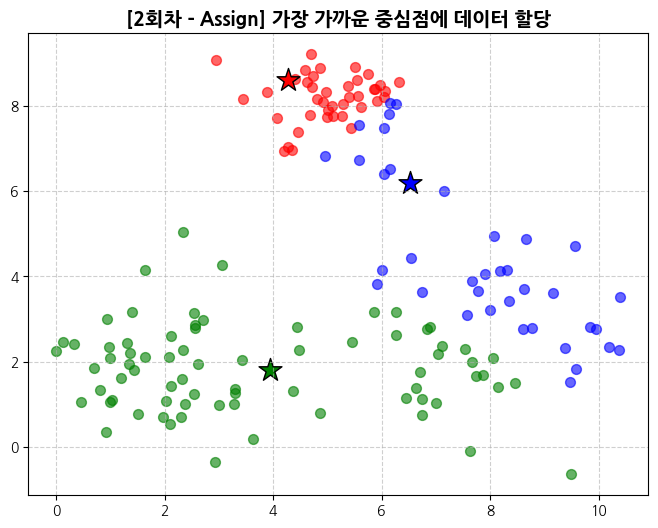

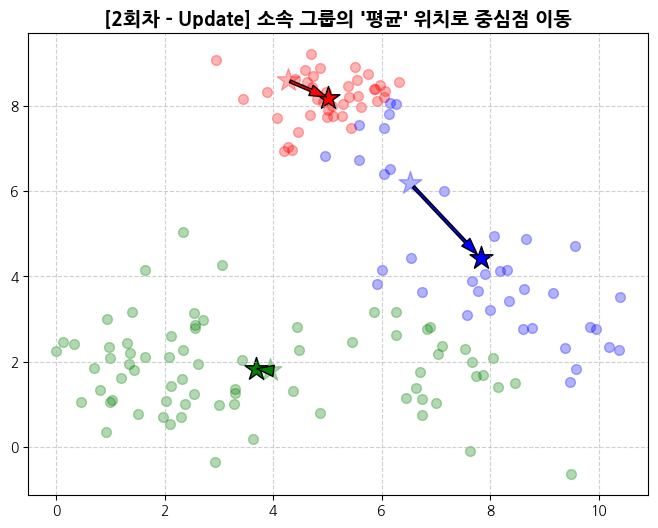

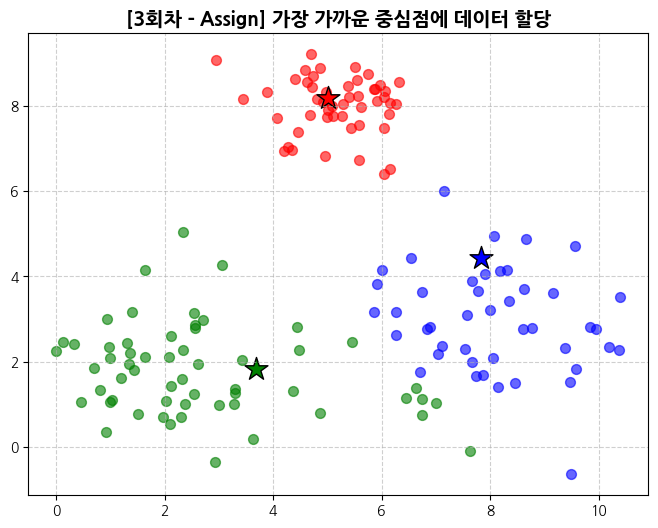

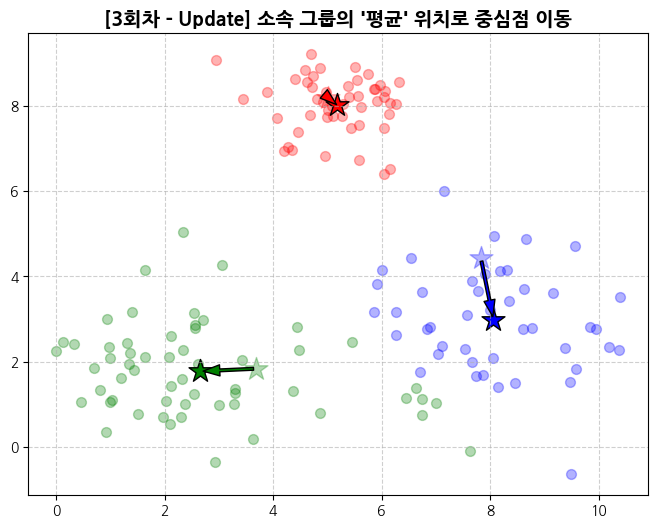

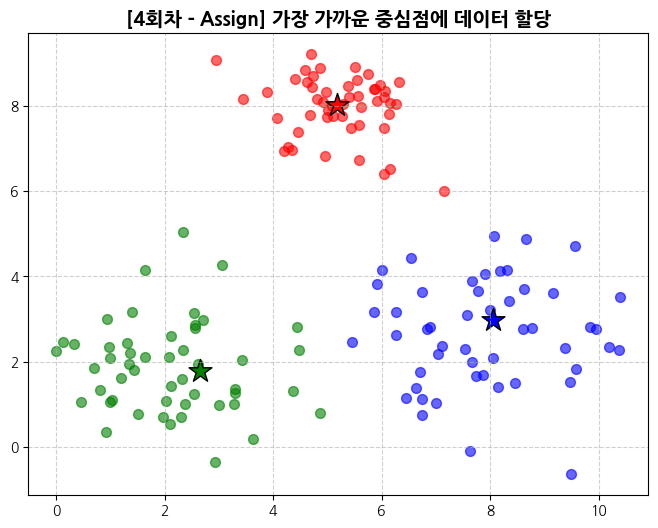

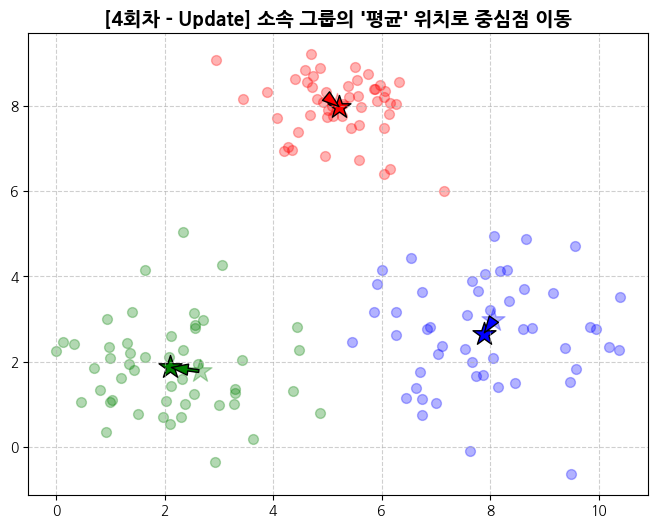

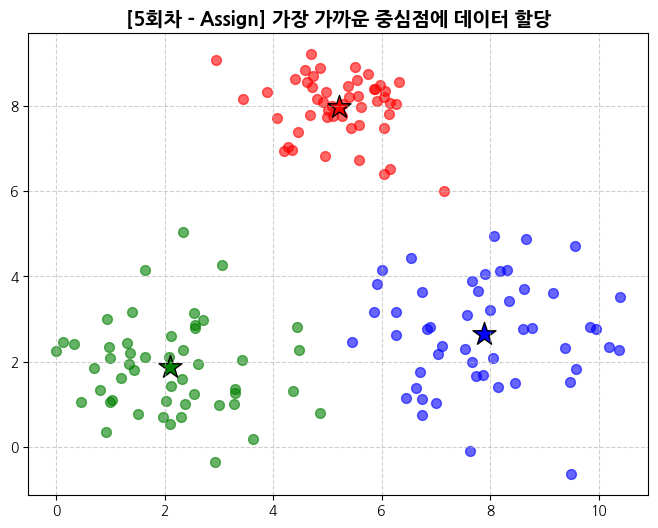

🎉 완벽하게 분류되었습니다! 5회차에서 중심점 이동이 멈추어 학습을 종료합니다.
K-Means 군집화 시각화 실습이 완료되었습니다.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import time

# 1. 랜덤 데이터 생성 (예: 3개의 군집으로 뭉쳐진 150개 데이터)
np.random.seed(None) # None으로 두면 실행할 때마다 데이터가 바뀝니다. (고정하려면 42 같은 숫자 입력)
N_SAMPLES = 50
cluster_1 = np.random.normal(loc=[2, 2], scale=1.0, size=(N_SAMPLES, 2))
cluster_2 = np.random.normal(loc=[8, 3], scale=1.2, size=(N_SAMPLES, 2))
cluster_3 = np.random.normal(loc=[5, 8], scale=0.8, size=(N_SAMPLES, 2))
X = np.vstack([cluster_1, cluster_2, cluster_3]) # 위 3개 그룹의 데이터를 하나로 합침

# K값 (군집 개수) 및 하이퍼파라미터 설정
K = 3
MAX_ITERS = 15 # 최대 반복 횟수 (무한 루프 방지)
colors = ['red', 'blue', 'green', 'orange', 'purple'] # K를 늘릴 경우를 대비한 여유 색상

# 2. 초기 중심점 무작위 설정 (전체 데이터 포인트 중 K개를 무작위로 뽑아 출발점으로 삼음)
random_indices = np.random.choice(len(X), K, replace=False)
centroids = X[random_indices].copy()

# ==========================================
# [Step 1] 초기 상태 (Initial State)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c='gray', s=50, alpha=0.5, label='Data Points')
for i in range(K):
    ax.scatter(centroids[i, 0], centroids[i, 1], c=colors[i], marker='*', s=300, edgecolor='black', label=f'C{i+1} (Init)')

ax.set_title("1. 초기 상태 (랜덤 데이터 & 무작위 중심점)", fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

# ==========================================
# [Step 2 & 3] 반복 업데이트 루프 (루프 시작)
# ==========================================
for iteration in range(1, MAX_ITERS + 1):
    time.sleep(1)
    # --- [Assign] 군집 할당 ---
    labels = []
    for point in X:
        # 각 중심점(C1, C2, C3)까지의 거리를 계산하여 리스트로 만듦
        distances = [np.sqrt((point[0] - c[0])**2 + (point[1] - c[1])**2) for c in centroids]
        # 거리가 가장 짧은(가장 가까운) 중심점의 인덱스(0, 1, 2)를 저장
        labels.append(np.argmin(distances))
    labels = np.array(labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(K):
        cluster_points = X[labels == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], s=50, alpha=0.6)
        ax.scatter(centroids[i, 0], centroids[i, 1], c=colors[i], marker='*', s=300, edgecolor='black')

    ax.set_title(f"[{iteration}회차 - Assign] 가장 가까운 중심점에 데이터 할당", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- [Update] 중심점 업데이트 ---
    new_centroids = np.zeros((K, 2))
    for i in range(K):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0) # 소속된 점들의 x, y 평균 계산
        else:
            new_centroids[i] = centroids[i] # 소속된 점이 없으면 제자리 유지

    # 🚀 종료 조건 (Break): 새로운 중심점이 예전 중심점과 100% 똑같다면(이동이 없다면)
    if np.all(centroids == new_centroids):
        print(f"🎉 완벽하게 분류되었습니다! {iteration}회차에서 중심점 이동이 멈추어 학습을 종료합니다.")
        break

    # 궤적 그리기
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(K):
        cluster_points = X[labels == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], s=50, alpha=0.3)
        # 예전 중심점 (반투명)
        ax.scatter(centroids[i, 0], centroids[i, 1], c=colors[i], marker='*', s=300, alpha=0.3)
        # 새로운 중심점 (진하게)
        ax.scatter(new_centroids[i, 0], new_centroids[i, 1], c=colors[i], marker='*', s=300, edgecolor='black')
        # 이동 화살표
        ax.annotate('', xy=new_centroids[i], xytext=centroids[i],
                    arrowprops=dict(facecolor=colors[i], shrink=0.05, width=2, headwidth=8))

    ax.set_title(f"[{iteration}회차 - Update] 소속 그룹의 '평균' 위치로 중심점 이동", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # 중심점을 새로운 위치로 완전히 갱신
    centroids = new_centroids.copy()

# 최종 완료 메시지
print("K-Means 군집화 시각화 실습이 완료되었습니다.")

#🦠 전염병처럼 퍼져나가는 DBSCAN의 군집 계산 원리 (수학적 원리 포함)
K-Means가 위에서 아래로 중심점을 찍어 통제하는 '하향식'이라면, DBSCAN은 데이터 하나에서 출발해 조건이 맞으면 주변으로 계속 뻗어나가는 '상향식(전염 방식)'입니다.이를 엄밀하게 이해하기 위해, 알고리즘의 기준이 되는 하이퍼파라미터와 데이터의 3가지 상태를 수학적 정의와 함께 살펴보겠습니다.
  1. 두 가지 기준 (하이퍼파라미터)와 거리 계산식알고리즘이 시작되기 전, 사람은
컴퓨터에게 딱 두 가지 기준만 알려주면 됩니다.
  * $\epsilon$ (Epsilon, 엡실론): "내 주변이라고 인정할 반경 크기 (거리 기준)
  * "$MinPts$ (Min Samples, 최소 이웃 수): "이 반경 안에 최소 몇 명의 데이터가 있어야 빽빽하다고 인정할 것인가? (밀도 기준)"📐 [수학적 기초] 유클리드 거리와 엡실론 이웃두 점 $p(x_1, y_1)$와 $q(x_2, y_2)$ 사이의 거리 $\text{dist}(p, q)$는 보통 유클리드 거리 공식을 사용합니다.$$\text{dist}(p, q) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$이를 바탕으로, 어떤 점 $p$의 $\epsilon$-반경 이웃(Epsilon-neighborhood)의 집합 $N_{\epsilon}(p)$는 다음과 같이 정의됩니다. 전체 데이터 집합을 $D$라고 할 때:$$N_{\epsilon}(p) = \{q \in D \mid \text{dist}(p, q) \le \epsilon\}$$(해석: 전체 데이터 중, 점 $p$와의 거리가 $\epsilon$ 이하인 모든 점 $q$들의 집합)
  2. 데이터 점들의 3가지 신분 (수학적 정의)DBSCAN은 위 기준을 바탕으로 모든 데이터를 다음 세 가지 중 하나로 분류합니다. 집합의 원소 개수를 의미하는 절댓값 기호 $| \cdot |$ 를 사용해 정의합니다.
      1. 👑 핵심 점 (Core Point) : "동네의 인싸"조건: 내 반경 안에 있는 이웃의 수(나 자신 포함)가 $MinPts$ 이상인 점.수학적 정의: 어떠한 점 $p$가 다음을 만족할 때 핵심 점이 됩니다.$$|N_{\epsilon}(p)| \ge MinPts$$역할: 데이터가 충분히 빽빽하게 모여있음을 증명하며, 새로운 군집을 시작하는 출발점이 됩니다.
      2. 🧍‍♂️경계 점 (Border Point) : "인싸의 친구"조건: 내 반경 안의 이웃이 $MinPts$ 개 미만이지만, 이웃 중에 '핵심 점'이 최소 1개 이상 포함된 점.수학적 정의: $p$가 핵심 점이 아니면서 ($|N_{\epsilon}(p)| < MinPts$), 어떤 핵심 점 $q$의 반경 이웃에 속하는 경우 ($p \in N_{\epsilon}(q)$).역할: 밀도가 아주 높지는 않지만 핵심 점과 연결되어 있으므로 같은 군집의 가장자리(경계)로 합류합니다.
      3. 👻 노이즈 (Noise/Outlier) : "독고다이 (이상치)"조건: 핵심 점도 아니고, 경계 점도 아닌 모든 점.수학적 정의: 주변 이웃도 부족하고 ($|N_{\epsilon}(p)| < MinPts$), 어떤 핵심 점의 반경 안에도 속하지 않는 점 ($p \notin N_{\epsilon}(q)$ for any core point $q$).역할: 알고리즘에 의해 불량품 혹은 노이즈로 처리되어 버려집니다. (보통 라벨 -1이 부여됨)
  3. 꼬리를 무는 전염 과정 (도달 가능성)DBSCAN이 군집을 확장해 나가는 과정은 밀도 도달 가능성(Density-Reachability)이라는 수학적 개념으로 설명됩니다.직접 밀도 도달 가능 (Directly Density-Reachable): 점 $p$가 핵심 점 $q$의 반경 안에 있다면 ($p \in N_{\epsilon}(q)$), $p$는 $q$로부터 '직접 밀도 도달이 가능하다'고 합니다. (내 직접적인 1차 친구)밀도 도달 가능 (Density-Reachable):점 $p_1, p_2, \dots, p_n$ 이 있을 때, $p_1$이 핵심 점이고 $p_{i+1}$이 $p_i$로부터 직접 밀도 도달이 가능하다면, 징검다리를 건너듯 $p_n$은 $p_1$로부터 '밀도 도달이 가능하다'고 합니다. (친구의 친구의 친구... 로 연결됨)밀도 연결 (Density-Connected):어떤 핵심 점 $o$로부터 점 $p$와 점 $q$가 모두 '밀도 도달 가능'하다면, 점 $p$와 $q$는 서로 '밀도 연결되어 있다'고 합니다.🔥 군집(Cluster)의 수학적 결론:DBSCAN에서 하나의 군집 $C$는 "서로 밀도 연결된(Density-Connected) 점들의 최대 집합"으로 정의됩니다.
  4. 군집이 만들어지는 4단계 과정 (알고리즘 동작)
      1. 무작위 찌르기: 컴퓨터가 데이터 공간에서 무작위로 아직 방문하지 않은 점 하나($p$)를 선택합니다.
      2. 핵심 점 판별: 그 점의 거리 식 $\text{dist}(p, q) \le \epsilon$을 계산하여 $|N_{\epsilon}(p)| \ge MinPts$ 인지 봅니다.만족하면? ➡️ "새로운 군집 시작!"불만족하면? ➡️ 일단 노이즈로 보류.
      3. 바이러스 전염 (밀도 도달 가능성 탐색): 핵심 점으로 판명된 $p$의 이웃 $N_{\epsilon}(p)$ 집합을 큐(Queue)에 넣고, 이 점들도 핵심 점인지 연쇄적으로 검사합니다.이웃 점 중 핵심 점이 발견되면 그 점의 이웃들도 큐에 추가하여 탐색 영역을 계속 확장($Union$)해 나갑니다.더 이상 추가될 점이 없으면 하나의 거대한 군집이 완성됩니다.
      4. 반복 및 종료: 아직 방문하지 않은 남은 점들 중 하나를 다시 무작위로 선택해 2~3 과정을 반복합니다. 모든 점을 다 방문하고 나면 알고리즘이 종료됩니다.